# Exercise 2 - CNNs, ResNets and LR-Scheduling

 * Deep Learning for Computer Vision – Winter Term 2025/26
 * Lecture by: Constantin Pape
 * Organizers: Anwai Archit, Sushmita Nair
 * Tutors: Azhar Akhmetova, Benjamin Eckhardt, Carolin Teuber, Luca Freckmann, Marei Freitag, Oleg Bakumenko, Sarah Muth
 * Due date: **Tuesday, Nov 25, before 10:00**

### Time required to solve this exercise sheet
**As you will train a large number of models on this exercise sheet, model training will require an increased amount of time. So we recommend to start working on this sheet early.**

### Topics

In this exercise sheet, you will:
- work again with CIFAR-10
- implement a 1-layer CNN
- compare MLP and CNN
- vary architecture to improve model performance
- implement a ResNet for CIFAR-10
- learn about learning rate scheduling

*We are looking forward to seeing your solutions! Have fun!*

## IMPORTANT SUBMISSION INSTRUCTIONS

- **You need to answer all questions in written form!**
- When you've completed the exercise, download the notebook and rename it to `<surname1>_<surname2>_<surname3>.ipynb`
- Only submit the Jupyter Notebook (.ipynb file). No other file is required.
    - Upload it on `Stud.IP` -> `Deep Learning for Computer Vision` -> `Files` -> `Submission of Homework 2` -> `Tutorial X` (where X is the tutorial you are assigned to).
- Make only one submission of the exercise per group.
- The deadline is strict.
- You have to present the exercise in the tutorials. We have a high ratio of students to tutors, so please decide which team member presents which part beforehand

Implementation:
- Do not change the cells which are marked as `DO NOT CHANGE`, similarly write your solution into the cells marked with TODOs for the questions asked.

### How to work on the exercise?
You will need access to a machine with a GPU to properly work on the exercises. We recommend using [JupyterHPC](https://jupyter.hpc.gwdg.de/), which offers convenient access to a GPU. We have provided access to all the dependencies that we need preinstalled ([here](https://docs.google.com/document/d/1frgBvU9ZRcR7PkMqOuK5eTj5RphZBmjz_i6OgA1DVwE/edit?usp=sharing) are the initial steps and step-by-step guide to get started with working on JupyterHPC).

In addition, another recommended solution would be using [Kaggle](https://www.kaggle.com/), which also offers convenient access to a GPU and has all the dependencies that we need preinstalled ([here](https://gist.github.com/anwai98/444d3ff11c1365f2c610579d5df0830b) are the initial steps to work the Kaggle Notebooks). You can load this notebook on Kaggle via `File` -> `Import Notebook` -> `Browse Files` and `Import`.

### Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, ExponentialLR, StepLR
import torchvision
from torchvision import datasets, transforms, models
import fastprogress
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import time
from pathlib import Path
import os
import sys
import time
import importlib

In [2]:
colab = False

In [3]:
if colab:
    project_path = Path('/content')
else:
    project_path = Path(os.environ.get("PROJECT")).resolve()

## 1. Setup

You can use the functions to grab the data, split the sets, create the dataloaders and plot results, etc. given to you at exercise sheet 1.

It is good practice to store functions that are constantly needed again in a separate file such that instead of copy-pasting the cells into each exercise notebook, you can use the python file containing the functions and import it in the notebooks.

If you use JupyterHPC (recommended), the file with functions from exercise 1 is already uploaded to `$PROJECT/utils/setup.py`.

Hint:
To load a custom script from path you can use `importlib` module together with this code:
```python
spec = importlib.util.spec_from_file_location("module_name", module_path)
s = importlib.util.module_from_spec(spec) # we call it s for setup
spec.loader.exec_module(s)
```
and validate it for example by getting the device: `s.get_device()`.

Alternatively you can copy the file to your workspace using terminal `cp $PROJECT/utils/setup.py $HOME/your/notebook/location/` and import as usuall:

`import setup as s`


#### For Kaggle users
If you work with Kaggle you have to mount the drive first and create a path to your python module or download the file from drive.
Create a file named `setup.py` and copy all the necessary functions to it, e.g. dataset preparation and training.

Alternativelly you can download this file to your workspace from drive and import it on this notebook.
File URL is https://drive.google.com/file/d/1066jDUxp8fXwdcNGj8h0CWJA0KNLpvKk/view?usp=share_link

Hint:
For download you can use the package `gdown`

```python
!conda install -y gdown
!gdown <file_id>
```

where, `file_id` is "1066jDUxp8fXwdcNGj8h0CWJA0KNLpvKk"

Then, setup.py should be added to your workspace and you can import it as usual module `import setup as s`

In [4]:
if colab:
    # KAGGLE or Google Colab
    import gdown
    !gdown "1066jDUxp8fXwdcNGj8h0CWJA0KNLpvKk"
    import setup as s
else:
    # GWDG Jupyter HPC
    spec = importlib.util.spec_from_file_location("setup", os.path.join(project_path, "utils/setup.py"))
    s = importlib.util.module_from_spec(spec) # we call it s for setup
    spec.loader.exec_module(s)

## 2. Load dataset, create dataloader, etc.

#### **TODO**
Call the functions of `setup.py` to instantiate the train-, test- and validation CIFAR10 datasets along with their dataloaders.

In [5]:
device = s.get_device()
device

cuda available: True; cudnn available: True; num devices: 1
Using device NVIDIA A100-SXM4-80GB MIG 1g.10gb


device(type='cuda', index=0)

In [7]:
data_dir = Path(project_path, "data", "Ex1")
batch_size = 512

# TODO: Grab data, generate split and initialize data loaders
trainset, testset = s.grab_data(data_dir)
trainset, valset =s.generate_train_val_data_split(trainset)
trainloader, valloader, testloader = s.init_data_loaders(trainset, valset, testset)

In [8]:
print("Train size:", len(trainset))
print('Val Size:', len(valset))
print("Test size :", len(testset))

Train size: 40000
Val Size: 10000
Test size : 10000


#### **TODO**
Define the loss function. We use the cross entropy loss again.

In [9]:
# TODO: Define loss function
loss_fn = nn.CrossEntropyLoss().to(device)

## 3. Simple 1-layer CNN model

### **TODO**
- Define the model.

The first step to training a model is defining its architecture.
Define a sequential model with following structure:
*   Convolutional layer with 32 filters, kernel size of 5*5 and stride of 1.
*   Max Pooling layer with kernel size of 2*2 and default stride.
*   ReLU Activation Layers.
*   Linear layer with output of 512.
*   ReLU Activation Layers.
*   A linear layer with output of 10.

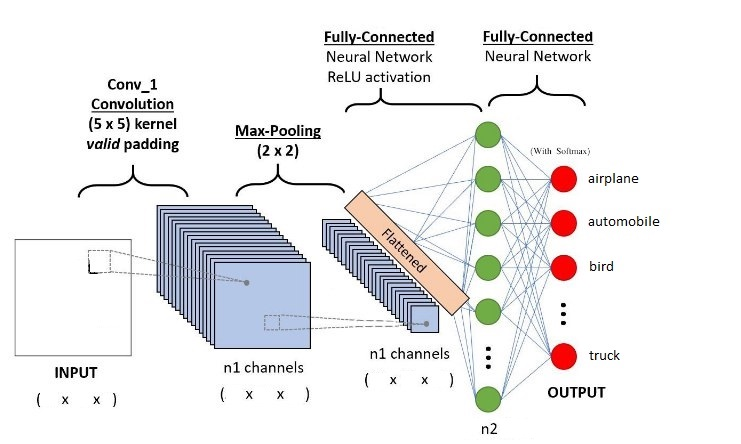

#### **Questions**

- What are the input dimensions?
- What are the dimensions of the feature maps?
- What are the dimensions after pooling?
- What is the size of each input (i.e value of `in_features`) to the first fully connected linear layer?
- What is the number of parameters for conv_1?

**Your answers here**

- Input dimensions: 32 x 32 x 3
- Feature map dimensions: 28 x 28 x 32
- Dimensions after pooling: 14 x 14 x 32
- Size of `in_features`: flatten 14 x 14 x 32 = 6272
- Number of parameters for `conv_1`: 5 x 5 x 32 = 800

In [10]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=5, stride=1),
            nn.MaxPool2d(kernel_size=2), # Halving the Dimensions
            nn.ReLU(inplace=True),
            nn.Flatten(),     # Flattening the output of Conv to input it into the Linear     Layer
            nn.Linear(32 * 14 * 14, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.seq(x)

#### **TODO**

- Train the model for 10 epochs. Try lr=0.001 (can be changed to suit other design choices you make)
- Plot the results of accuracy and loss as you did in exercise sheet 1.

In [11]:
# TODO: Train and plot
model = CNNModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = s.run_training(
    model, optimizer, loss_fn, device, num_epochs = 10,
    train_dataloader = trainloader, val_dataloader = valloader, verbose = True)

Finished training after 107 seconds.


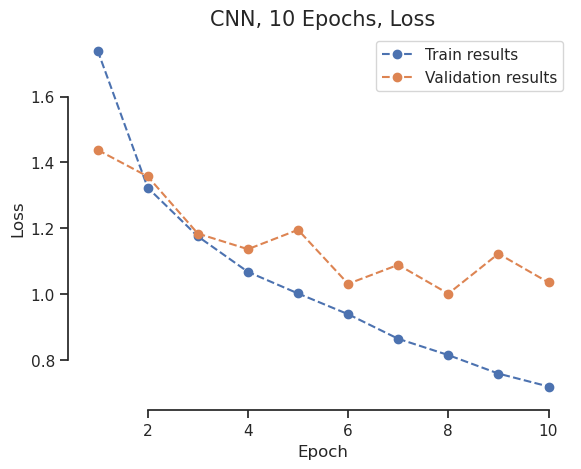

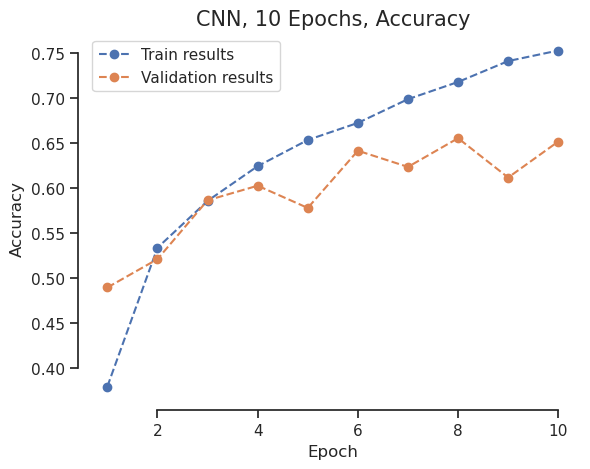

In [12]:
s.plot(title='CNN, 10 Epochs, Loss' , label='Loss', val_results = val_losses, train_results = train_losses)
s.plot(title='CNN, 10 Epochs, Accuracy' , label='Accuracy', val_results = val_accs, train_results = train_accs)

#### **TODO**
Compare results to the MLP models you trained in Exercise 1. What can you observe?

**Your answers here**


The validation accuracy from the first try with CNNs is way better (around %65) than from the MLP (around 45% to 50%) after several steps of finetuning and 100 epochs of training. The same also holds for the loss which is significantly better for the CNN model.

**For your reference, below is the loss and accuracy plots of an MLP model trained in Exercise sheet 1:**

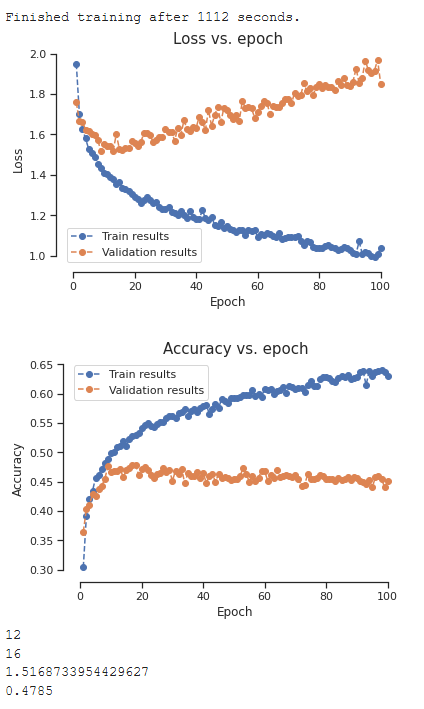

#### **TODO**
Train longer (ca. 60 epochs), plot again.

In [13]:
# TODO: Train and plot
model = CNNModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = s.run_training(
    model,optimizer,loss_fn,device,num_epochs = 60,
    train_dataloader = trainloader, val_dataloader = valloader, verbose = True)

Finished training after 642 seconds.


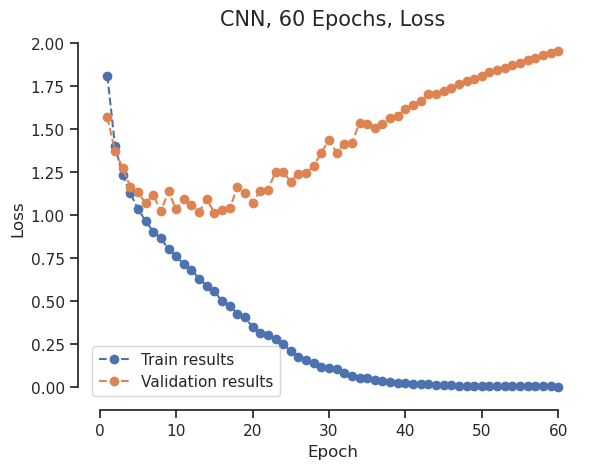

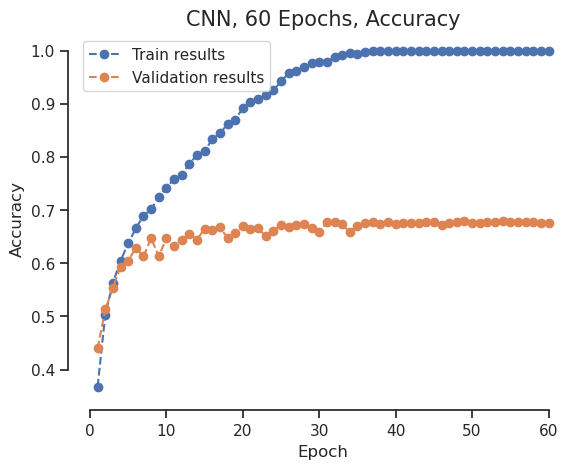

In [15]:
s.plot(title='CNN, 60 Epochs, Loss' , label='Loss', val_results = val_losses, train_results = train_losses)
s.plot(title='CNN, 60 Epochs, Accuracy' , label='Accuracy', val_results = val_accs, train_results = train_accs)

#### **Questions**
- Why is that not an optimal model?
- What could be improved?

**Your answers here**

- The model is very quickly overfitted, after about 15 epochs the validation loss increases steadily while the training loss still falls.
- The training accuracy reaches 100% at some point, while the validation accuracy plateaus at 65%-70% indicating strong overfitting
- When the validation accuracy plateaus, one could decrease the learning rate
- The CNN convolutions cannot filter complex geometries as there are not sufficiently many layers to reprsent them. Instead the model just "remembers" images and classes. Therefore add more CNN layers.  

## 4. CNN model with more convolutional layers

#### **TODO**
Define the architecture using the following information:



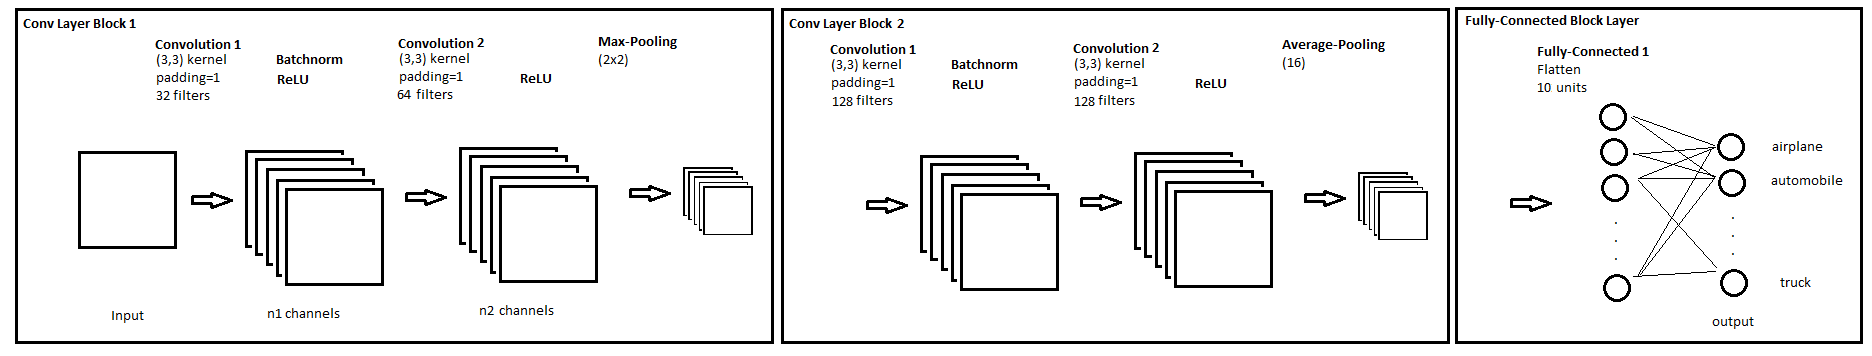

*   Convolutional layer 1: with 32 filters, kernel size of 3*3 and padding 1.
*   Batchnorm and ReLU layers
*   Convolutional layer 2: with 64 filters, kernel size of 3*3 and padding 1.
*   ReLU Activation layer
*   Max pooling with kernel size of 2*2
*   Convolutional layer 3: with 128 filters, kernel size of 3*3 and padding 1.
*   Batchnorm and ReLU layers
*   Convolutional layer 4: with 128 filters, kernel size of 3*3 and padding 1.
*   ReLU Activation layer
*   Average pooling with kernel size 16*16
*   Fully connected layer

#### **Questions**

- Padding is used in the convolutional layers. What does that mean, which variants exist and how does it influence the dimensions of the feature maps?
- What does padding=1 mean in the case of the network displayed above?
- What are the dimensions of the feature maps after the 1. conv layer?
- What are the dimensions of the feature maps after the 2. conv layer?
- What ist the receptive field size after the first two convolutions?
- What is the value for the in_features for the fully-connected layer?
- What is the number of parameters of *Conv Layer block 1*?

**Your answers here**

- Convulutions reduce the dimensions of the input. To avoid this, adding a padding of zeros can be introduced. The option "same" adds as much zeros needed to keep the output dimensions the same as the input dimensions. Otherwise, "valid" just means that there is no paading applied.
- Padding=1 means a border with thickness 1 of zero pixels that is added to the input image
- Feature maps after 1. conv layer: 32 x 32 x 32
- Feature maps after 2. conv layer: 32 x 32 x 64
- RF after first two convolutions: 1+(3-1)+(3-1) = 5
- in_features = 128
- Number of parameters in conv layer block 1:
  - convolutions: 3x3x32 + 3x3x64 = 864
  - batch norm (2 learnable params per channel): 32x2 = 64

In [16]:
# TODO: Define model 2
class ModifiedCNNModel(nn.Module):
    def __init__(self):
        super(ModifiedCNNModel, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1,stride =1)
        # 32 * 32 * 32
        self.bnorm1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU() # Constant ReLU Layer Throughout
        self.conv2 = nn.Conv2d(in_channels = 32, out_channels = 64, stride = 1, kernel_size = 3, padding = 1)
        # 64 * 32 * 32
        self.maxpool = nn.MaxPool2d(kernel_size = 2)
        # 64 * 16 * 16
        self.conv3 = nn.Conv2d(in_channels = 64, out_channels = 128, stride = 1, kernel_size = 3, padding = 1)
        # 128 * 16 * 16
        self.bnorm2 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(in_channels = 128, out_channels = 128, stride = 1, kernel_size = 3, padding = 1)
        # 128 * 16 *16
        self.avgpool = nn.AvgPool2d(kernel_size = 16)
        # 128 * 1 * 1
        self.linear = nn.Linear(128 , out_features = 10)

    def forward(self,x):
        # Conv Block 1
        x = self.conv1(x)
        x = self.bnorm1(x)
        x = self.relu(x)
        # Conv Block 2
        x = self.conv2(x)
        x = self.relu(x)
        x = self.maxpool(x)
        # Conv Block 3
        x = self.conv3(x)
        x = self.bnorm2(x)
        x = self.relu(x)
        # Conv Block 4
        x = self.conv4(x)
        x= self.relu(x)
        x = self.avgpool(x)
        # Flatten and Linear Layer
        x = torch.flatten(x,1)
        x = self.linear(x)

        return x

#### **TODO**

- train the new net (30 epochs, try lr=0.1 or change as necessary), plot the results, and compare the results to the 1-layer CNN
- explain why you observe these results

In [17]:
# TODO: Train and plot
model = ModifiedCNNModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = s.run_training(
    model,optimizer,loss_fn,device,num_epochs = 30,
    train_dataloader = trainloader, val_dataloader = valloader, verbose = True)

Finished training after 438 seconds.


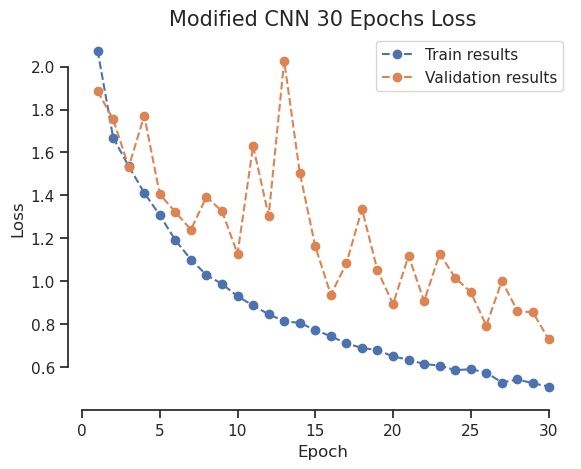

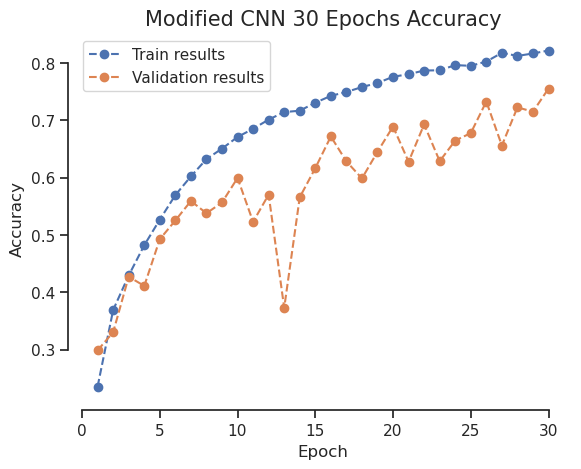

In [18]:
s.plot(title='Modified CNN 30 Epochs Loss' , label='Loss', val_results = val_losses, train_results = train_losses)
s.plot(title='Modified CNN 30 Epochs Accuracy' , label='Accuracy', val_results = val_accs, train_results = train_accs)

## 5. ResNet architecture

"*Deeper neural networks are more difficult to train.  We present a residual learning framework to ease the training of networks that are substantially deeper than those used previously.*" [ https://arxiv.org/pdf/1512.03385.pdf]

That was the intention of He et al. to develop residual networks.

A ResNet is built of blocks which are called the *Residual Blocks*.
A residual block uses *skip connections* - shortCuts — to jump over some layers to skip some activations.
The Resnet skips connections via addition.

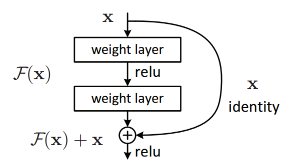

#### **Questions**
- Which problems do using skip connections solve?
- Why is a residual network called residual?

**Your answers here**

- Skip connections solve the degradation problem:
  - theoretically a shallow network and a deep network with many identity mapping layers should  be able to approximate the desired output similarly well
  - however solvers tend to have problems approximating identity layers with many non-linear layers
  - the residual formulation of the problem separates the non-linear mapping into an identity and a residual part
  - solvers can simply drive weights to zero if identity is optimal
- The desired mapping $F$ is divided into an identity $\mathrm{id}$ and residual part $H := F - \mathrm{id}$, then parameters for the residual $H$ are learned

#### **TODO**
- write a class **ResidualBlock(nn.Module)** where you define the blocks used in the ResNet
- write a class **ResNet(nn.Module)** where you define the model
- Train the model and plot results
- Train another model by disable residual connections and compare performance

![resnet_copy.jpg](attachment:469eb159-8c38-403c-af7c-21fd87465853.jpg)

**Hints**

- The downsampling in this ResNet happens between layer 1 and layer 2. In this step, the channel size is increased (32 -> 64) and the image resolution is downsampled by strided convolution (stride=2 in the Conv2d layers).
- For the adding part, the dimensions obviously have to be the same. This is accomplished by using stride=2 in the first Conv2d layer of the block while the second layer does not change the dimensions.
- The average-pooling layer has kernel size 7.
- For you to ensure everything works fine, here are the shapes in the form [(batchsize), x, y, channel] where I discard batchsize, because it does not change.
32x32x3 -> conv 7x7 -> 14x14x32 -> layer 1 -> 14x14x32 -> layer2 -> 7x7x64 -> avpool(7) -> 1x1x64 -> linear(64, 10)

In [19]:
# TODO: Write a class ResidualBlock(nn.Module) where you define the blocks used in the ResNet
class ResidualBlock(nn.Module):

    def __init__(self, in_channels = 32 , out_channels = 32, downsample = False, use_skip = True):
        super(ResidualBlock, self).__init__()

        self.use_skip = use_skip
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.downsample = downsample

        first_stride = 2 if downsample else 1

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=first_stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.res_block = nn.Sequential(
          self.conv1,
          self.bn1,
          self.relu,
          self.conv2,
          self.bn2
        )


        if downsample:
          self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(out_channels)
          )
        else:
          self.shortcut = nn.Identity()

        self.out_relu = nn.ReLU()


    def forward(self, x):
        if self.use_skip:
          out = self.res_block(x) + self.shortcut(x)
        else:
          out = self.res_block(x)

        return self.out_relu(out)

In [20]:
# TODO: Write a class ResNet(nn.Module) where you define the model

class ResNet(nn.Module):

  def __init__(self, in_channels = 3, use_skip = True):
    super().__init__()

    self.conv7x7 = nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=7, stride=2, padding=1)
    self.batch_norm_1 = nn.BatchNorm2d(32)

    self.layer_1 = nn.Sequential(
        ResidualBlock(in_channels=32, out_channels=32, downsample=False, use_skip=use_skip),
        ResidualBlock(in_channels=32, out_channels=32, downsample=False, use_skip=use_skip)
    )

    self.layer_2 = nn.Sequential(
        ResidualBlock(in_channels=32, out_channels=64, downsample=True, use_skip=use_skip),
        ResidualBlock(in_channels=64, out_channels=64, downsample=False, use_skip=use_skip)
    )

    self.fully_connected = nn.Linear(in_features=64, out_features=10)

    self.model = nn.Sequential(
        self.conv7x7,
        self.batch_norm_1,
        nn.ReLU(),
        self.layer_1,
        self.layer_2,
        nn.AvgPool2d(kernel_size=7),
        nn.Flatten(),
        self.fully_connected
    )

  def forward(self, x):

    return self.model(x)

In [21]:
# TODO: Train ResNet using the architecture laid out in the comments and figures above. Plot loss and accuracy for training and validation set.
model = ResNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = s.run_training(
    model, optimizer, loss_fn,device,num_epochs = 30,
    train_dataloader = trainloader, val_dataloader = valloader, verbose = True)


Finished training after 352 seconds.


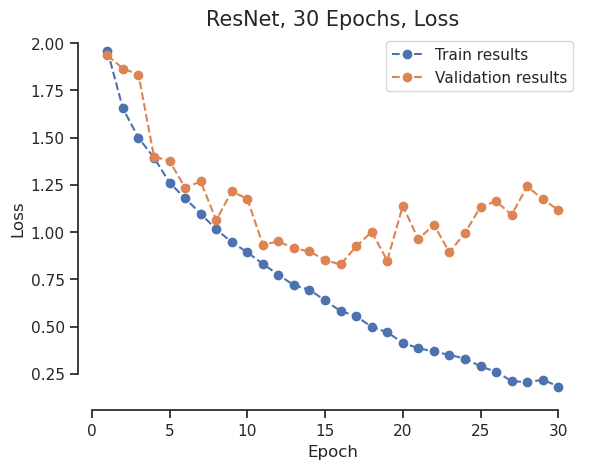

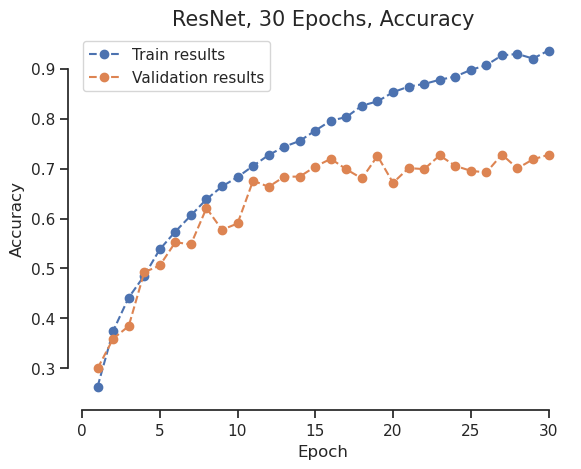

In [22]:
s.plot(title='ResNet, 30 Epochs, Loss' , label='Loss', val_results = val_losses, train_results = train_losses)
s.plot(title='ResNet, 30 Epochs, Accuracy' , label='Accuracy', val_results = val_accs, train_results = train_accs)

In [23]:
# TODO: Train another model by disabling all residual connections. Plot loss and accuracy curves for training and validation set.
model = ResNet(use_skip=False).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = s.run_training(
    model, optimizer, loss_fn,device,num_epochs = 30,
    train_dataloader = trainloader, val_dataloader = valloader, verbose = True)

Finished training after 341 seconds.


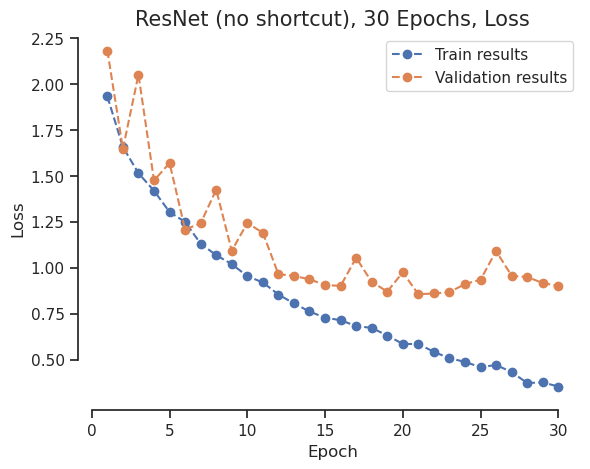

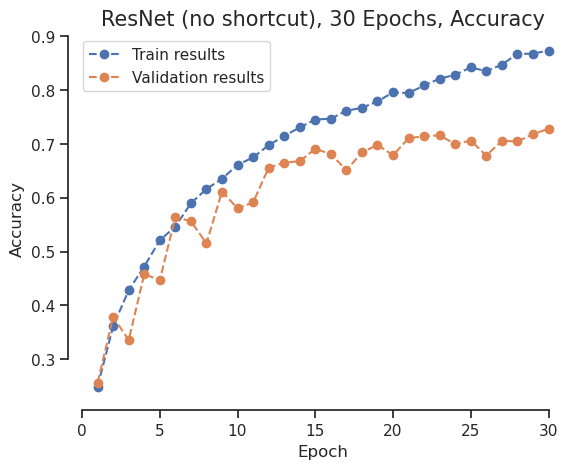

In [24]:
s.plot(title='ResNet (no shortcut), 30 Epochs, Loss' , label='Loss', val_results = val_losses, train_results = train_losses)
s.plot(title='ResNet (no shortcut), 30 Epochs, Accuracy' , label='Accuracy', val_results = val_accs, train_results = train_accs)

#### **Questions**
- Does using residual connections result in better performance in this exercise? If yes, why? If not, when would the benefit of using ResNet be most visible?
- In deeper networks, how would you expect residual blocks to influence training time? why?
- Compare the performance and training time of your ResNet with the CNNs you trained in the previous section.

**Your answers here**

- the train loss of ResNet with shortcuts is lower as well as the train accuracy is better than for the ResNet without shortcuts
- for the validation metrics, the difference is not that large
- the advantage of identity shortcuts probably is more significant for deeper networks
- for deeper networks, if identities are of advantage to approximate the desired output function, it is easier to push the residual weights towards zero, so training time could be lower
- the ResNets perform better than the CNNs in the previous section with validation accuracy above 70%

## 6. Explore Learning Rate Scheduling

Learning rate scheduling is a mechanism to adjust the learning rate.

*`torch.optim.lr_scheduler`* provides several methods based on the number of epochs. Learning rate scheduling should be applied after optimizer’s update.

#### **TODO**
- change run_training and extend to use scheduler for learning rate
- use `StepLR` (https://pytorch.org/docs/stable/optim.html), use the ResNet, train for 10 epochs. Start with a learning rate of 0.1.


#### **Questions**

- Try step size 1, gamma 0.1
    - How does it change the learning rate?
    - what do you observe regarding performance?
- Try step size 1, gamma 0.9, what do you observe?
    - How does it change the learning rate?
    - what do you observe regarding performance?
- What can you conclude of this experiment regarding the synergy of step size and gamma to get a good schedule?

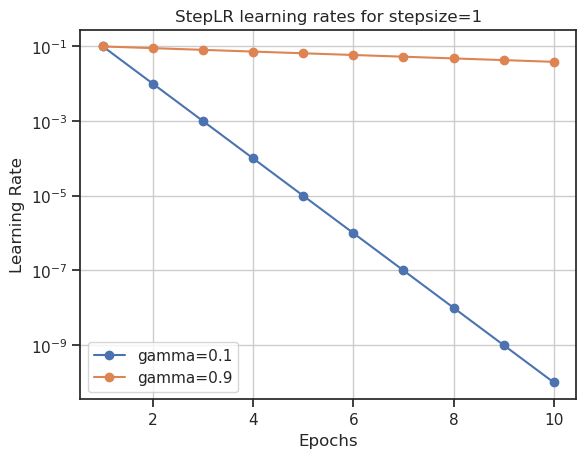

In [25]:
epochs = np.arange(1, 11)
gamma_exp_1 = np.log(0.1)
gamma_exp_2 = np.log(0.9)
learning_rates_1 = np.exp(gamma_exp_1*(epochs-1))*0.1
learning_rates_2 = np.exp(gamma_exp_2*(epochs-1))*0.1
plt.plot(epochs, learning_rates_1, label="gamma=0.1", marker="o")
plt.plot(epochs, learning_rates_2, label="gamma=0.9", marker="o")
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Learning Rate")
plt.title("StepLR learning rates for stepsize=1")
plt.grid()
plt.legend()
plt.show()

**Your answers here**

- The learning rates decay exponentially
- For $\gamma=0.9$ the decay is very little, while for $\gamma=0.1$ it is one order of magnitude per step
- This can be seen in the graphs below: for $\gamma=0.9$, the loss and accuracy curve is equal to the curves above for the first 10 epochs
- In contrast, the curve for $\gamma=0.1$ are basically equal to stopping training after 3 epochs. The decay of the learning rate was too quick.
- For a good schedule, the stepsize must be increased, while the value for $\gamma=0.1$ is usually a good choice
- The stepsize is ideally fitted to match beginnings of plateaus in the learning curve

In [26]:
# @title
# TODO: Change run_training (you can copy the code from setup.py here and create a new method here
# or just change/create a new method it in the python file)
def run_training_scheduler(model, optimizer, loss_function, device, num_epochs,
                train_dataloader, val_dataloader, early_stopper=None, scheduler=None, verbose=False):
    """Run model training.

    Args:
        model (nn.Module): Torch model to train
        optimizer: Torch optimizer object
        loss_fn: Torch loss function for training
        device (torch.device): Torch device to use for training
        num_epochs (int): Max. number of epochs to train
        train_dataloader (DataLoader): Torch DataLoader object to load the
            training data
        val_dataloader (DataLoader): Torch DataLoader object to load the
            validation data
        early_stopper (EarlyStopper, optional): If passed, model will be trained
            with early stopping. Defaults to None.
        verbose (bool, optional): Print information about model training.
            Defaults to False.

    Returns:
        list, list, list, list, torch.Tensor shape (10,10): Return list of train
            losses, validation losses, train accuracies, validation accuracies
            per epoch and the confusion matrix evaluated in the last epoch.
    """
    start_time = time.time()
    master_bar = fastprogress.master_bar(range(num_epochs))
    train_losses, val_losses, train_accs, val_accs = [],[],[],[]

    for epoch in master_bar:
        # Train the model
        epoch_train_loss, epoch_train_acc = s.train(train_dataloader, optimizer, model,
                                                  loss_function, device, master_bar)
        # Validate the model
        epoch_val_loss, epoch_val_acc, confusion_matrix = s.validate(val_dataloader,
                                                                   model, loss_function,
                                                                   device, master_bar)

        # Update LR scheduler
        if scheduler:
            scheduler.step()

        # Save loss and acc for plotting
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accs.append(epoch_train_acc)
        val_accs.append(epoch_val_acc)

        if verbose:
            master_bar.write(f'Train loss: {epoch_train_loss:.2f}, val loss: {epoch_val_loss:.2f}, train acc: {epoch_train_acc:.3f}, val acc {epoch_val_acc:.3f}')

        if early_stopper:
            early_stopper.update(epoch_val_acc, model)
            if early_stopper.early_stop:
                model = early_stopper.load_checkpoint(model)
                print('early stopping')
                break
            # END OF YOUR CODE #

    time_elapsed = np.round(time.time() - start_time, 0).astype(int)
    print(f'Finished training after {time_elapsed} seconds.')
    return train_losses, val_losses, train_accs, val_accs, confusion_matrix

In [27]:
# TODO: Train and plot with step size 1, gamma 0.1

model = ResNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer=optimizer, step_size=1, gamma=0.1)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training_scheduler(
    model, optimizer, loss_fn,device,num_epochs = 10,
    train_dataloader = trainloader, val_dataloader = valloader, verbose = True, scheduler=scheduler)

Finished training after 116 seconds.


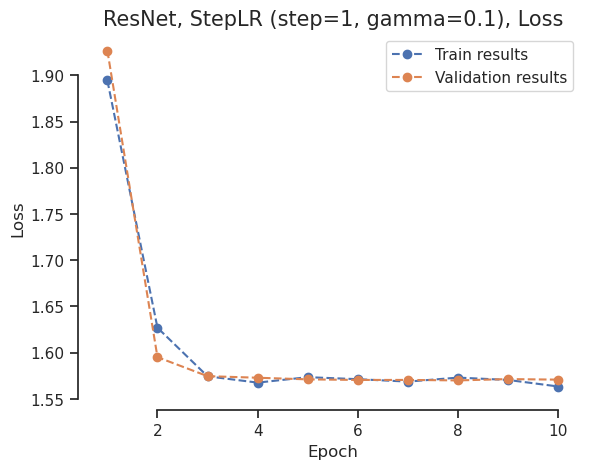

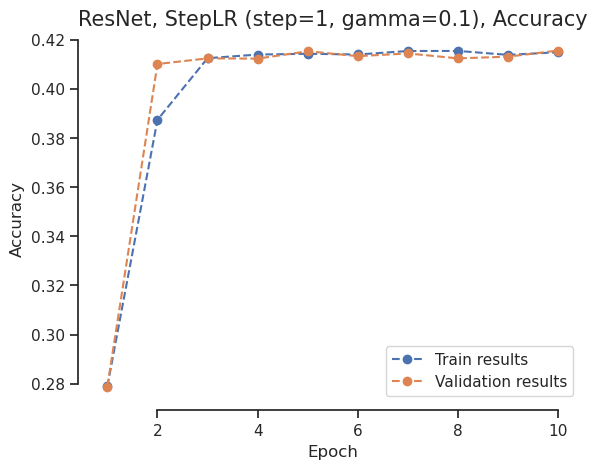

In [28]:
s.plot(title='ResNet, StepLR (step=1, gamma=0.1), Loss' , label='Loss', val_results = val_losses, train_results = train_losses)
s.plot(title='ResNet, StepLR (step=1, gamma=0.1), Accuracy' , label='Accuracy', val_results = val_accs, train_results = train_accs)

In [29]:
# TODO: Train and plot with step size 1, gamma 0.9

model = ResNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer=optimizer, step_size=1, gamma=0.9)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training_scheduler(
    model, optimizer, loss_fn,device,num_epochs = 10,
    train_dataloader = trainloader, val_dataloader = valloader, verbose = True, scheduler=scheduler)

Finished training after 117 seconds.


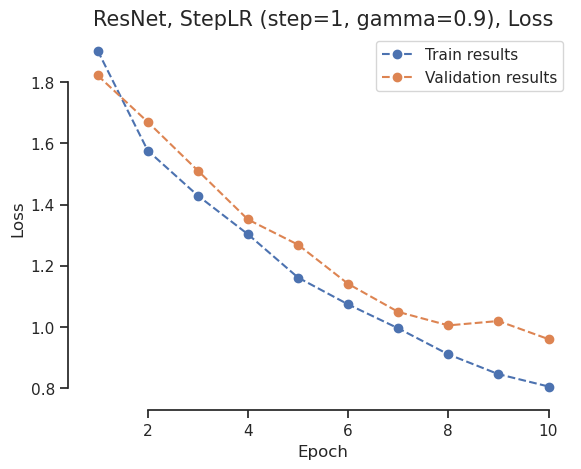

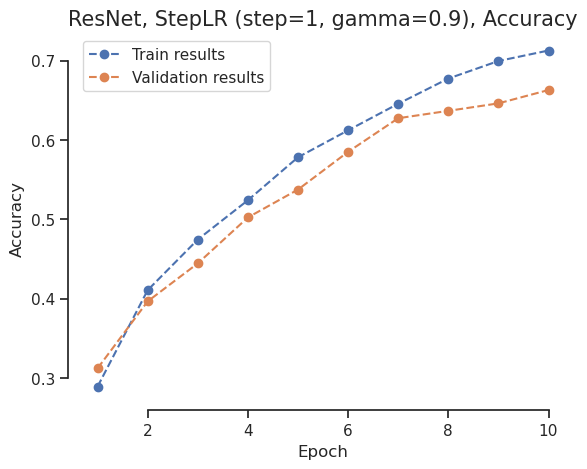

In [30]:
s.plot(title='ResNet, StepLR (step=1, gamma=0.9), Loss' , label='Loss', val_results = val_losses, train_results = train_losses)
s.plot(title='ResNet, StepLR (step=1, gamma=0.9), Accuracy' , label='Accuracy', val_results = val_accs, train_results = train_accs)

#### **TODO**

Use step size 15, gamma 0.1. Train for 30 epochs.

In [31]:
# TODO: Train and plot with step size 15, gamma 0.1, 30 epochs.

model = ResNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer=optimizer, step_size=15, gamma=0.1)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training_scheduler(
    model, optimizer, loss_fn,device,num_epochs = 30,
    train_dataloader = trainloader, val_dataloader = valloader, verbose = True, scheduler=scheduler)

Finished training after 345 seconds.


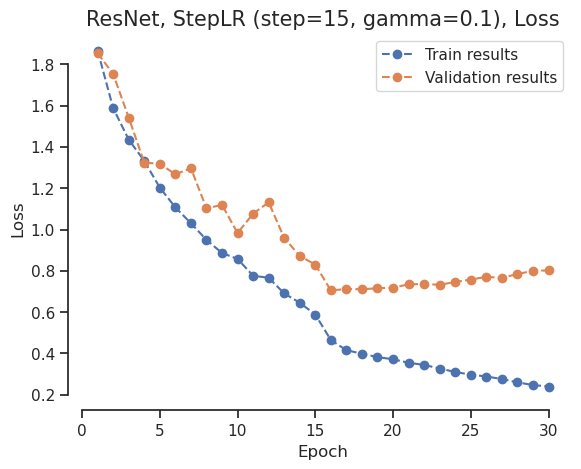

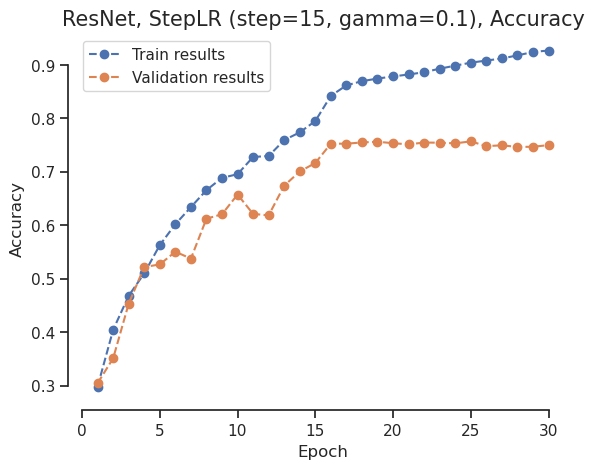

In [32]:
s.plot(title='ResNet, StepLR (step=15, gamma=0.1), Loss' , label='Loss', val_results = val_losses, train_results = train_losses)
s.plot(title='ResNet, StepLR (step=15, gamma=0.1), Accuracy' , label='Accuracy', val_results = val_accs, train_results = train_accs)

#### **Questions**
- Does it improve performance?
- What can you observe in the plots?

**Your answers here**

- Yes, the performance of 75% on the validation set is better than before
- The loss and accuracy of the train and validation sets stabilizes after epoch 14 as the learning rate is reduced

## 7. LR-Scheduling _(Optional)_

#### TODO _(Optional)_
- try two more scheduler: ExponentialLR and ReduceLROnPlateau
- vary the parameters, which work best?
- does it improve performance compared to no scheduler?
- does it improve performance compared to StepLR?

In [ ]:
# TODO (Optional): Train and plot with different schedulers

**Your answers here**